In [ ]:
!nvidia-smi


Fri Aug 21 21:00:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 6.7 MB/s eta 0:00:00


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving section1_detection.zip to section1_detection.zip


In [ ]:
import zipfile
from pathlib import Path

zip_path = Path("/content/section1_detection.zip")
extract_root = Path("/content")

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_root)

print("Extracted.")

Extracted.


In [ ]:
from pathlib import Path
import yaml

dataset_root = Path("/content/data/processed/detection")

config = {
    "path": str(dataset_root),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": 1,
    "names": ["pallet"],
}

yaml_path = dataset_root / "data_colab.yaml"

with open(yaml_path, "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

print(yaml_path)
print(yaml.safe_dump(config, sort_keys=False))

/content/data/processed/detection/data_colab.yaml
path: /content/data/processed/detection
train: images/train
val: images/val
test: images/test
nc: 1
names:
- pallet



In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

results = model.train(
    data="/content/data/processed/detection/data_colab.yaml",
    epochs=50,
    imgsz=640,
    batch=-1,
    patience=10,
    device=0,
    workers=2,
    project="/content/runs_section1",
    name="pallet_detector",
    exist_ok=True,
    pretrained=True,
    seed=42,
)


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/processed/detection/data_colab.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr

In [ ]:
detector = YOLO(
    "/content/runs_section1/pallet_detector/weights/best.pt"
)

metrics = detector.val(
    data="/content/data/processed/detection/data_colab.yaml",
    split="test",
    imgsz=640,
    device=0,
)

Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 44.5±36.8 MB/s, size: 184.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/data/processed/detection/labels/test... 135 images, 12 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 135/135 474.3it/s 0.3s
val: New cache created: /content/data/processed/detection/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.1it/s 8.3s
                   all        135       1873      0.947      0.958      0.968      0.694
Speed: 8.0ms preprocess, 13.9ms inference, 0.0ms loss, 4.5ms postprocess per image
Results saved to /content/runs/detect/val


In [ ]:
print(metrics.results_dict)

{'metrics/precision(B)': 0.9473174501860614, 'metrics/recall(B)': 0.9583555792845702, 'metrics/mAP50(B)': 0.9680754537292873, 'metrics/mAP50-95(B)': 0.6936669167680494, 'fitness': 0.6936669167680494}


In [ ]:
from pathlib import Path
import shutil

output = Path("/content/section1_models")
output.mkdir(exist_ok=True)

shutil.copy(
    "/content/runs_section1/pallet_detector/weights/best.pt",
    output / "pallet_detector_best.pt"
)

print(list(output.iterdir()))

[PosixPath('/content/section1_models/pallet_detector_best.pt')]


In [ ]:
!find /content/runs_section1 -maxdepth 3 -type f | sort | head -50

/content/runs_section1/pallet_detector/args.yaml
/content/runs_section1/pallet_detector/BoxF1_curve.png
/content/runs_section1/pallet_detector/BoxP_curve.png
/content/runs_section1/pallet_detector/BoxPR_curve.png
/content/runs_section1/pallet_detector/BoxR_curve.png
/content/runs_section1/pallet_detector/confusion_matrix_normalized.png
/content/runs_section1/pallet_detector/confusion_matrix.png
/content/runs_section1/pallet_detector/labels.jpg
/content/runs_section1/pallet_detector/results.csv
/content/runs_section1/pallet_detector/results.png
/content/runs_section1/pallet_detector/train_batch0.jpg
/content/runs_section1/pallet_detector/train_batch1.jpg
/content/runs_section1/pallet_detector/train_batch2360.jpg
/content/runs_section1/pallet_detector/train_batch2361.jpg
/content/runs_section1/pallet_detector/train_batch2362.jpg
/content/runs_section1/pallet_detector/train_batch2.jpg
/content/runs_section1/pallet_detector/val_batch0_labels.jpg
/content/runs_section1/pallet_detector/val_b

In [ ]:
!ls -lh /content/runs_section1/pallet_detector/

total 9.4M
-rw-r--r-- 1 root root 1.7K Aug 21 21:42 args.yaml
-rw-r--r-- 1 root root 101K Aug 21 21:58 BoxF1_curve.png
-rw-r--r-- 1 root root  86K Aug 21 21:58 BoxP_curve.png
-rw-r--r-- 1 root root  80K Aug 21 21:58 BoxPR_curve.png
-rw-r--r-- 1 root root  97K Aug 21 21:58 BoxR_curve.png
-rw-r--r-- 1 root root  95K Aug 21 21:58 confusion_matrix_normalized.png
-rw-r--r-- 1 root root 100K Aug 21 21:58 confusion_matrix.png
-rw-r--r-- 1 root root 141K Aug 21 21:42 labels.jpg
-rw-r--r-- 1 root root 6.0K Aug 21 21:57 results.csv
-rw-r--r-- 1 root root 273K Aug 21 21:58 results.png
-rw-r--r-- 1 root root 598K Aug 21 21:42 train_batch0.jpg
-rw-r--r-- 1 root root 535K Aug 21 21:42 train_batch1.jpg
-rw-r--r-- 1 root root 519K Aug 21 21:55 train_batch2360.jpg
-rw-r--r-- 1 root root 534K Aug 21 21:55 train_batch2361.jpg
-rw-r--r-- 1 root root 552K Aug 21 21:55 train_batch2362.jpg
-rw-r--r-- 1 root root 603K Aug 21 21:42 train_batch2.jpg
-rw-r--r-- 1 root root 895K Aug 21 21:58 val_batch0_labels.jpg

In [ ]:
!ls -lh /content/runs_section1/pallet_detector/results.csv

-rw-r--r-- 1 root root 6.0K Aug 21 21:57 /content/runs_section1/pallet_detector/results.csv


In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/runs_section1/pallet_detector/results.csv"
)

print(df.columns.tolist())
print(df.tail(10).to_string(index=False))

['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
 epoch    time  train/box_loss  train/cls_loss  train/dfl_loss  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss   lr/pg0   lr/pg1   lr/pg2
    41 767.234         0.89088         0.54720         0.94532               0.94905            0.96398           0.98307              0.73713       0.93854       0.57886       1.03438 0.000416 0.000416 0.000416
    42 785.495         0.86110         0.50443         0.92883               0.94654            0.96529           0.98159              0.72298       0.90288       0.57233       0.98791 0.000376 0.000376 0.000376
    43 802.674         0.85505         0.53983         0.93532               0.93940            0.97380           0.98204     

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/runs_section1/pallet_detector/weights/best.pt"
)

train_metrics = model.val(
    data="/content/data/processed/detection/data_colab.yaml",
    split="train",
    imgsz=640,
    device=0
)

test_metrics = model.val(
    data="/content/data/processed/detection/data_colab.yaml",
    split="test",
    imgsz=640,
    device=0
)

print("\nTRAIN:")
print(train_metrics.results_dict)

print("\nTEST:")
print(test_metrics.results_dict)

Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2404.8±1045.2 MB/s, size: 375.1 KB)
val: Scanning /content/data/processed/detection/labels/train.cache... 644 images, 38 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 644/644 67.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 41/41 2.0it/s 20.4s
                   all        644       6929      0.962      0.981      0.979      0.752
Speed: 2.6ms preprocess, 11.8ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /content/runs/detect/val-2
Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1542.9±442.8 MB/s, size: 236.0 KB)
val: Scanning /content/data/processed/detection/labels/test.cache... 135 images, 12

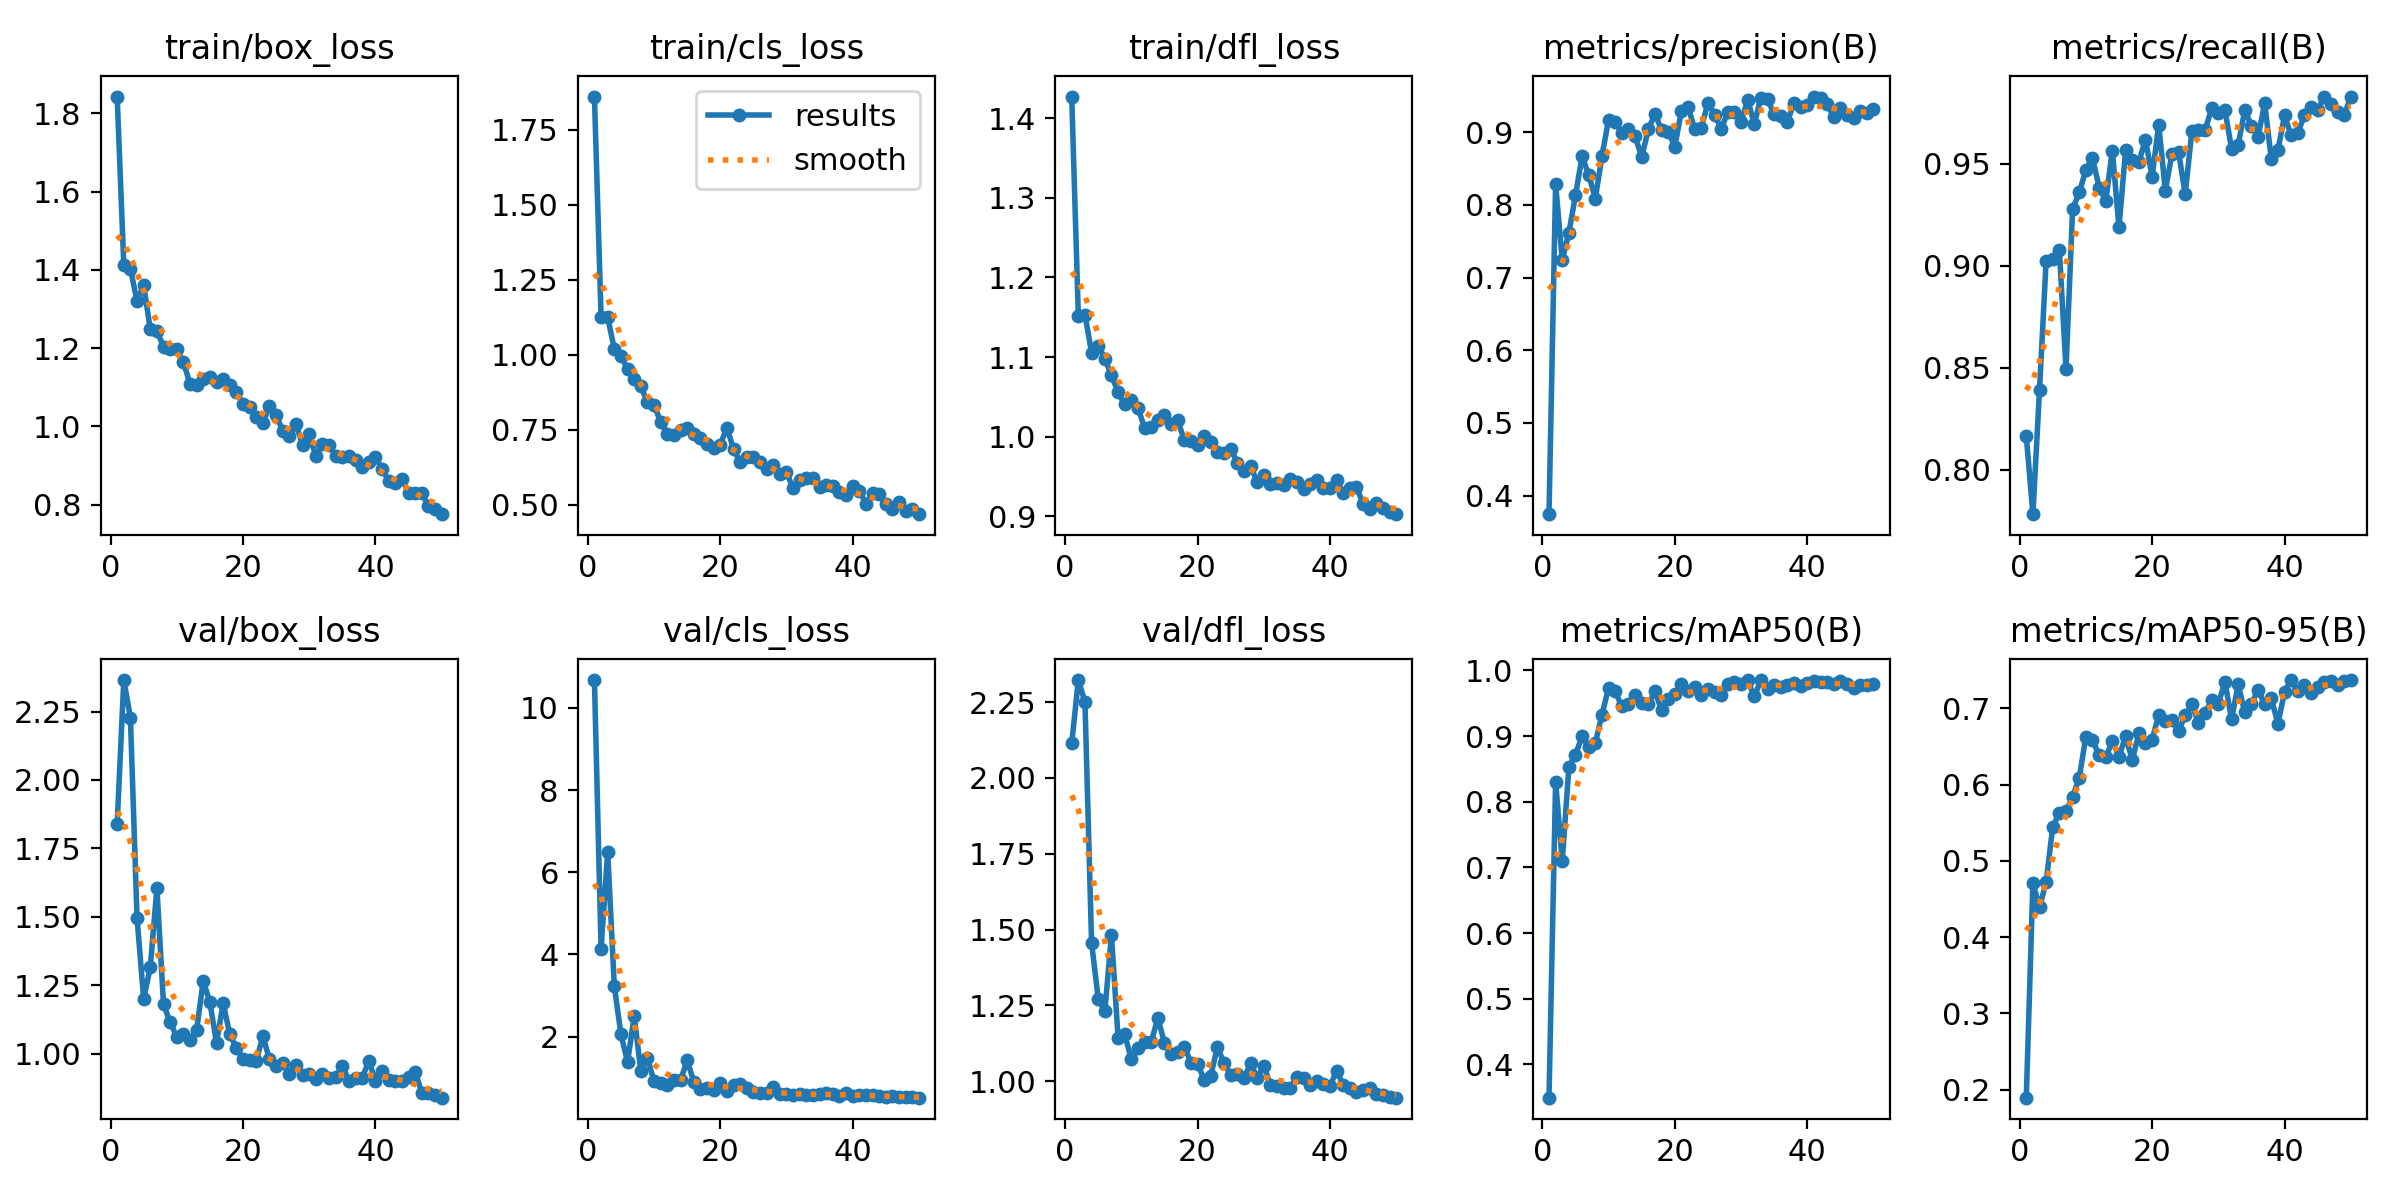

In [ ]:
from IPython.display import Image, display

display(
    Image(
        filename="/content/runs_section1/pallet_detector/results.png"
    )
)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving section1_geometry.zip to section1_geometry.zip


In [ ]:
import zipfile
from pathlib import Path

zip_path = Path("/content/section1_geometry.zip")

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("/content")

print("Geometry dataset extracted.")

Geometry dataset extracted.


In [ ]:
!find /content/data/processed/geometry -maxdepth 2 -type d | sort

/content/data/processed/geometry
/content/data/processed/geometry/images
/content/data/processed/geometry/images/test
/content/data/processed/geometry/images/train
/content/data/processed/geometry/images/val
/content/data/processed/geometry/labels
/content/data/processed/geometry/labels/test
/content/data/processed/geometry/labels/train
/content/data/processed/geometry/labels/val


In [ ]:
from pathlib import Path
import yaml

dataset_root = Path("/content/data/processed/geometry")

config = {
    "path": str(dataset_root),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": 1,
    "names": ["pallet_front"],
}

yaml_path = dataset_root / "data_colab.yaml"

with open(yaml_path, "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

print(yaml_path)
print(yaml.safe_dump(config, sort_keys=False))

/content/data/processed/geometry/data_colab.yaml
path: /content/data/processed/geometry
train: images/train
val: images/val
test: images/test
nc: 1
names:
- pallet_front



In [ ]:

from ultralytics import YOLO

geometry_model = YOLO("yolo11s-seg.pt")

results = geometry_model.train(
    data="/content/data/processed/geometry/data_colab.yaml",
    epochs=75,
    imgsz=640,
    batch=-1,
    patience=15,
    device=0,
    workers=2,
    project="/content/runs_section1",
    name="pallet_geometry",
    exist_ok=True,
    pretrained=True,
    seed=42,
)

Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/processed/geometry/data_colab.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=75, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pallet_ge

In [ ]:
geometry_model = YOLO(
    "/content/runs_section1/pallet_geometry/weights/best.pt"
)

geometry_test = geometry_model.val(
    data="/content/data/processed/geometry/data_colab.yaml",
    split="test",
    imgsz=640,
    device=0
)

print(geometry_test.results_dict)

Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s-seg summary (fused): 114 layers, 10,067,203 parameters, 0 gradients, 32.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 89.7±30.2 MB/s, size: 1338.3 KB)
val: Scanning /content/data/processed/geometry/labels/test... 63 images, 26 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 63/63 366.5it/s 0.2s
val: New cache created: /content/data/processed/geometry/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.2s/it 4.9s
                   all         63         37      0.947          1      0.981      0.898      0.947          1      0.981      0.887
Speed: 9.1ms preprocess, 30.1ms inference, 0.0ms loss, 5.4ms postprocess per image
Results saved to /content/runs/segment/val
{'metrics/precision(B)': 0.9469029768143981, 'metrics/recall(B)': 1.0, 'metrics/mAP50(B)': 0.981153846

In [ ]:
from pathlib import Path
import shutil

output = Path("/content/section1_models")
output.mkdir(exist_ok=True)

shutil.copy(
    "/content/runs_section1/pallet_geometry/weights/best.pt",
    output / "pallet_geometry_best.pt"
)

print(list(output.iterdir()))

[PosixPath('/content/section1_models/pallet_detector_best.pt'), PosixPath('/content/section1_models/pallet_geometry_best.pt')]


In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/runs_section1/pallet_geometry/results.csv"
)

print(df.tail(10).to_string(index=False))

 epoch     time  train/box_loss  train/seg_loss  train/cls_loss  train/dfl_loss  train/sem_loss  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  metrics/mAP50-95(B)  metrics/precision(M)  metrics/recall(M)  metrics/mAP50(M)  metrics/mAP50-95(M)  val/box_loss  val/seg_loss  val/cls_loss  val/dfl_loss  val/sem_loss   lr/pg0   lr/pg1   lr/pg2
    52  858.629         0.50028         0.51997         0.38711         0.86400               0               0.99294            0.97619           0.99409              0.89093               0.99294            0.97619           0.99409              0.87892       0.32249       0.29628       0.31264       0.61985             0 0.000654 0.000654 0.000654
    53  873.952         0.50773         0.53489         0.40044         0.88224               0               1.00000            0.99975           0.99500              0.90336               1.00000            0.99975           0.99500              0.88025       0.31406       0.27763       0.28

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/runs_section1/pallet_geometry/weights/best.pt"
)

test_metrics = model.val(
    data="/content/data/processed/geometry/data_colab.yaml",
    split="test",
    imgsz=640,
    device=0
)

print(test_metrics.results_dict)

Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s-seg summary (fused): 114 layers, 10,067,203 parameters, 0 gradients, 32.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1665.2±1382.1 MB/s, size: 561.4 KB)
val: Scanning /content/data/processed/geometry/labels/test.cache... 63 images, 26 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 63/63 17.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.0it/s 3.9s
                   all         63         37      0.947          1      0.981      0.898      0.947          1      0.981      0.887
Speed: 10.5ms preprocess, 12.0ms inference, 0.0ms loss, 5.6ms postprocess per image
Results saved to /content/runs/segment/val-2
{'metrics/precision(B)': 0.9469029768143981, 'metrics/recall(B)': 1.0, 'metrics/mAP50(B)': 0.981153846153846, 'metrics/mAP50-95(B)': 0.8981166380403224, 'metrics/pre

In [ ]:
train_metrics = model.val(
    data="/content/data/processed/geometry/data_colab.yaml",
    split="train",
    imgsz=640,
    device=0
)

print("\nTRAIN:")
print(train_metrics.results_dict)

print("\nTEST:")
print(test_metrics.results_dict)

Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1182.6±379.1 MB/s, size: 466.0 KB)
val: Scanning /content/data/processed/geometry/labels/train.cache... 288 images, 89 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 288/288 75.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 1.3it/s 13.4s
                   all        288        199      0.993          1      0.993      0.912      0.993          1      0.993      0.907
Speed: 2.9ms preprocess, 11.9ms inference, 0.0ms loss, 3.9ms postprocess per image
Results saved to /content/runs/segment/val-3

TRAIN:
{'metrics/precision(B)': 0.9926067189506127, 'metrics/recall(B)': 1.0, 'metrics/mAP50(B)': 0.9927500000000001, 'metrics/mAP50-95(B)': 0.9124120441614162, 'metrics/precision(M)': 0.9926067189506127, 'metrics/recall(M)': 1.0, 'metrics/mAP50(M)

In [ ]:
from pathlib import Path
import shutil

src = Path(
    "/content/runs_section1/pallet_geometry/weights/best.pt"
)

dst = Path("/content/section1_models/pallet_geometry_best.pt")

dst.parent.mkdir(exist_ok=True)

shutil.copy2(src, dst)

print(dst)

/content/section1_models/pallet_geometry_best.pt


In [31]:
from google.colab import files

files.download(
    "/content/section1_models/pallet_detector_best.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
from google.colab import files
files.download(
    "/content/section1_models/pallet_geometry_best.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>